In [109]:
import pandas as pd
import numpy as np

import seaborn as sns

from ground_truth_comparison import euclidean_dist, match_gt_vio_ts, generate_error_gt_vio_pose

In [110]:
base_dir = '/home/shiva/Datasets/Kimera_VIO_Output'
working_dir = 'Custom_Dataset'
execution_folder_name = 'Movement_Table_Y_Forward_V1_Correct_Noise_Params'

use_output_log_dir = True

In [111]:
if use_output_log_dir:
    full_dir_path = f'{base_dir}/{working_dir}/{execution_folder_name}/output_logs'
else:
    full_dir_path = f'{base_dir}/{working_dir}/{execution_folder_name}'

In [112]:
# gt_df = pd.read_csv(f'{full_dir_path}/traj_gt.csv')
# gt_df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)

In [113]:
df_pose_est = pd.read_csv(f'{full_dir_path}/traj_vio.csv')
df_pose_est.rename(columns={'#timestamp': 'timestamp'}, inplace=True)

In [114]:
df_pose_est

,timestamp,x,y,z,qw,qx,qy,qz,vx,vy,vz,bgx,bgy,bgz,bax,bay,baz
0,1740758429367412992,0.000000e+00,0.000000,0.000000,0.685337,-0.056387,0.726039,0.000000,0.000000,0.000000,0.000000,-0.001399,-0.005358,-0.000034,0.064938,0.005043,0.003956
1,1740758429567412992,-3.318902e-05,0.000017,-0.000012,0.685258,-0.056423,0.726111,0.000069,0.000011,0.000004,-0.000404,-0.001430,-0.005317,-0.000024,0.065742,0.005116,0.004021
2,1740758429767412992,1.741016e-07,0.000089,-0.000111,0.685216,-0.056413,0.726152,0.000154,-0.000052,-0.000042,-0.000251,-0.001452,-0.005298,0.000004,0.066473,0.005172,0.004064
3,1740758429967412992,-4.095418e-05,0.000056,-0.000121,0.685070,-0.056331,0.726296,0.000165,0.000643,0.000338,-0.000006,-0.001440,-0.005180,0.000013,0.066487,0.005176,0.004071
4,1740758430167531008,3.715038e-05,0.000079,-0.000202,0.685011,-0.056304,0.726354,0.000160,0.000756,-0.000025,-0.000080,-0.001439,-0.005078,0.000028,0.066608,0.005185,0.004082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,1740758487168349952,7.003396e-01,-1.504956,0.741062,0.683545,-0.043672,0.728493,-0.012476,-0.001676,0.002411,0.002426,-0.001326,-0.004111,0.000321,0.047118,0.004122,-0.017587
269,1740758487368349952,7.002131e-01,-1.504595,0.741484,0.683514,-0.043725,0.728520,-0.012459,-0.000620,0.001705,0.002471,-0.001325,-0.004111,0.000321,0.047095,0.004019,-0.017676
270,1740758487568349952,7.000027e-01,-1.504372,0.741939,0.683504,-0.043823,0.728524,-0.012426,-0.000839,0.001248,0.003165,-0.001325,-0.004112,0.000320,0.047062,0.003913,-0.017733
271,1740758487768349952,6.998236e-01,-1.504207,0.742422,0.683446,-0.043860,0.728577,-0.012401,-0.002102,0.000526,0.002359,-0.001325,-0.004112,0.000320,0.047042,0.003758,-0.017764


In [115]:
df_pose_est[['x', 'y', 'z']].describe()

,x,y,z
count,273.000000,273.000000,273.000000
mean,0.232046,-0.115117,0.302454
std,0.284283,0.909715,0.274166
min,-0.061137,-1.604736,-0.009715
25%,-0.004640,-1.180723,0.002154
50%,0.124260,0.066096,0.402600
75%,0.532240,0.706500,0.539127
max,0.722816,1.015480,0.742835


In [116]:
df_to_plot = df_pose_est[['timestamp', 'x', 'y', 'z']]

/tmp/ipykernel_5067/318485464.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.lineplot(x='timestamp', y='value', hue='variable',


[Text(0.5, 0, 'Timestamp'),
 Text(0, 0.5, 'Displacement(m)'),
 Text(0.5, 1.0, 'Displacement vs Time (initial_k - 50)')]

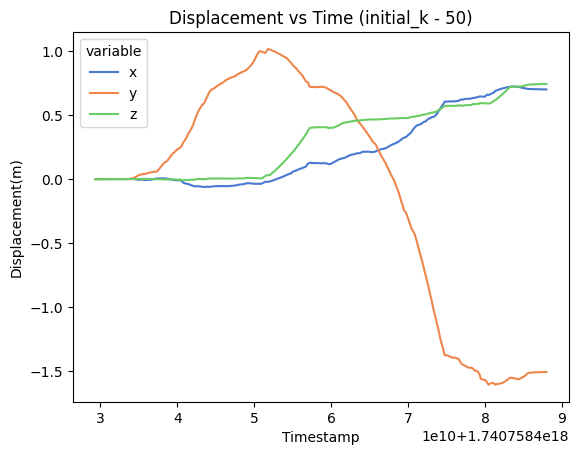

In [117]:
g = sns.lineplot(x='timestamp', y='value', hue='variable', 
             data=pd.melt(df_to_plot, ['timestamp']),
             palette=sns.color_palette("muted"))
g.set(xlabel ="Timestamp", ylabel = "Displacement(m)", title ='Displacement vs Time (initial_k - 50)')

## For Euroc Dataset Only

In [119]:
# Calculating error from Euroc dataset with no modifications.
# This was already done so no need to repeat.
# We will use these results to compare performance when noise is added!

# error_df = generate_error_gt_vio_pose(gt_df, df_pose_est, DEBUG=False, SHOW_GRAPHS=False)
# values = {'gt_x':error_df.iloc[-1]['gt_pos'][0],
#         'gt_y':error_df.iloc[-1]['gt_pos'][1],
#         'gt_z':error_df.iloc[-1]['gt_pos'][2],
#         'vio_x': error_df.iloc[-1]['vio_pos'][0],
#         'vio_y': error_df.iloc[-1]['vio_pos'][1],
#         'vio_z': error_df.iloc[-1]['vio_pos'][2],
#         'distance': error_df['distance'],
#         'error': error_df['error']
#         }
# default_v2_01_easy_results_df = pd.DataFrame(data={'Distance (m)': values['distance'], 'Error (m)':values['error']})
# default_v2_01_easy_results_df.to_csv('v2_01_easy_dist_vs_error.csv', index=False)

In [120]:
default_v2_01_easy_results_df = pd.read_csv('v2_01_easy_dist_vs_error.csv')
default_v2_01_easy_results_df['Execution'] = "Default"

In [121]:
error_df = generate_error_gt_vio_pose(gt_df, df_pose_est, DEBUG=False, SHOW_GRAPHS=False)

values = {'gt_x':error_df.iloc[-1]['gt_pos'][0],
        'gt_y':error_df.iloc[-1]['gt_pos'][1],
        'gt_z':error_df.iloc[-1]['gt_pos'][2],
        'vio_x': error_df.iloc[-1]['vio_pos'][0],
        'vio_y': error_df.iloc[-1]['vio_pos'][1],
        'vio_z': error_df.iloc[-1]['vio_pos'][2],
        'distance': error_df['distance'],
        'error': error_df['error']
        }
added_noise_v2_01_easy_results_df = pd.DataFrame(data={'Distance (m)': values['distance'], 'Error (m)':values['error']})
added_noise_v2_01_easy_results_df['Execution'] = "Added_Noise_1"

558
exception raised, so breaking out of loop: index 0 is out of bounds for axis 0 with size 0
Empty DataFrame
Columns: [gt_index, distance]
Index: []


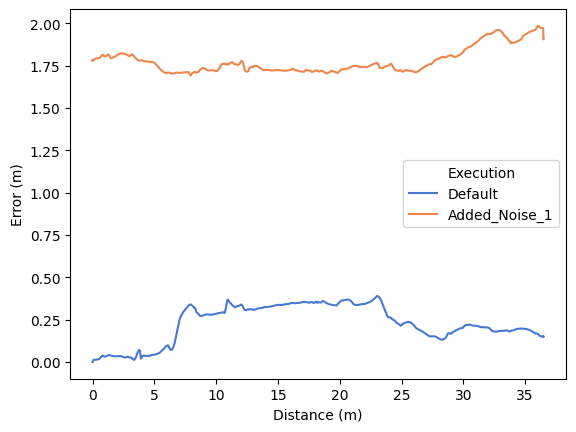

In [122]:
g = sns.lineplot(data = pd.concat([default_v2_01_easy_results_df, added_noise_v2_01_easy_results_df]), x='Distance (m)', y = 'Error (m)', hue='Execution', legend='full', palette='muted')